<a href="https://colab.research.google.com/github/SinelnikovaJulia/Stat_practicum/blob/main/3_prog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Serial test

Idea: break the sequence $x_1, x_2, x_3, ..., x_{2n}$ into consecutive series of length $2$: $(x_1, x_2), (x_3, x_4), ..., (x_{2n-1}, x_{2n})$ and look at each element as a random and independent point in $2D$ space. Next, apply chi-square. Similarly, one can construct series of length $3, 4$, etc.

### Problem 1
Implement serial test and apply to a `samples`

In [16]:
import numpy as np
from scipy.stats import chi2

def serial_test(samples, d=2, bins=10):
    n_blocks = len(samples) // d
    blocks = samples[:n_blocks * d].reshape(n_blocks, d)

    digits = np.floor(blocks * bins).astype(int)
    digits = np.clip(digits, 0, bins - 1)


    hist, _ = np.histogramdd(digits, bins=[np.arange(bins + 1)] * d)


    observed = hist.flatten()
    expected = n_blocks / (bins ** d)
    chi2_stat = np.sum((observed - expected) ** 2 / expected)
    dof = (bins ** d) - 1
    p_value = 1 - chi2.cdf(chi2_stat, dof)

    return chi2_stat, p_value, dof


np.random.seed(1)
samples = np.random.uniform(0, 1, 10000)

stat, p, dof = serial_test(samples, d=2, bins=10)
print(f"Хи-квадрат: {stat:.2f}")
print(f"p-значение: {p:.10f}")
print("Случайна" if p > 0.05 else "НЕ случайна")

Хи-квадрат: 82.20
p-значение: 0.8889463053
Случайна


### Problem 2*
Implement permutation test and apply to a `samples`

### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [45]:
import numpy as np
import scipy.stats as stats
from scipy import stats
from tqdm import tqdm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def rng_bad():
    m, a, c = 2**31, 65539, 0
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

rng_good = np.random.Generator(np.random.PCG64())
def random_spheres_test(generator, n=10000):
    samples = np.array([generator() for _ in range(n*3)]).reshape(n, 3)
    min_volumes = []

    for i in tqdm(range(0, n, 10)):  # Проверяем каждую 10-ю точку
        dists = np.sqrt(np.sum((samples - samples[i])**2, axis=1))
        dists[dists == 0] = np.inf
        min_volumes.append(4/3 * np.pi * np.min(dists)**3)
    return stats.kstest(min_volumes, 'expon', args=(0, np.mean(min_volumes)))

def enhanced_3d_test(generator, num_samples=10000):
    samples = np.array([generator() for _ in range(num_samples*3)]).reshape(num_samples, 3)

    fig = go.Figure(data=[go.Scatter3d(
        x=samples[:,0], y=samples[:,1], z=samples[:,2],
        mode='markers',
        marker=dict(size=2, opacity=0.5),
        name='3D распределение'
    )])

    fig.update_layout(
        title='3D тест распределения',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=800,
        height=600
    )
    fig.show()

    k = 20
    hist, _ = np.histogramdd(samples, bins=k)
    expected = num_samples / k**3
    chi2_stat = np.sum((hist.flatten() - expected)**2 / expected)
    p_value = 1 - stats.chi2.cdf(chi2_stat, k**3 - 1)

    return p_value

print("\n Тестирование плохого генератора ")
print("Тест минимальных сфер p-value:", random_spheres_test(rng_bad).pvalue)
print("3D серийный тест p-value:", enhanced_3d_test(rng_bad))

print("\n Тестирование хорошего генератора ")
print("Тест минимальных сфер p-value:", random_spheres_test(rng_good.random).pvalue)
print("3D серийный тест p-value:", enhanced_3d_test(rng_good.random))

print("\n Тестирование numpy.random.uniform ")
print("Тест минимальных сфер p-value:", random_spheres_test(np.random.uniform).pvalue)
print("3D серийный тест p-value:", enhanced_3d_test(np.random.uniform))



 Тестирование плохого генератора 


100%|██████████| 1000/1000 [00:00<00:00, 1050.91it/s]


Тест минимальных сфер p-value: 1.8993054481641092e-32


3D серийный тест p-value: 0.0

 Тестирование хорошего генератора 


100%|██████████| 1000/1000 [00:01<00:00, 894.89it/s]


Тест минимальных сфер p-value: 0.986812018546382


3D серийный тест p-value: 0.3569277680079114

 Тестирование numpy.random.uniform 


100%|██████████| 1000/1000 [00:00<00:00, 1222.52it/s]


Тест минимальных сфер p-value: 0.536815156228573


3D серийный тест p-value: 0.7369976057887457


### Problem 4

Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

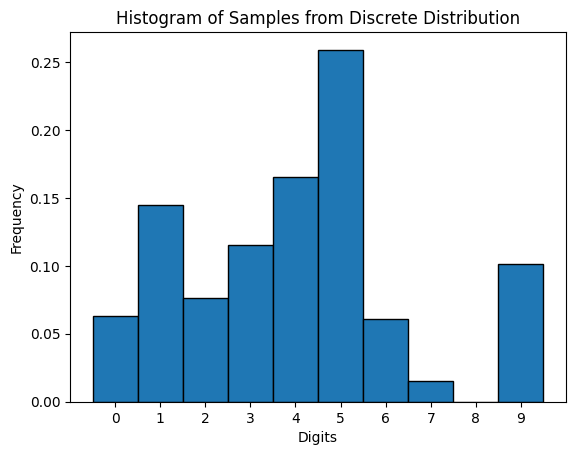

In [5]:

import numpy as np
import matplotlib.pyplot as plt
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

normalized_weights = weights / np.sum(weights)

sorted_indices = np.argsort(normalized_weights)[::-1]
sorted_weights = normalized_weights[sorted_indices]

cdf = np.cumsum(sorted_weights)

random_samples = []
for _ in range(1000):
    rand = np.random.random()
    digit = np.searchsorted(cdf, rand)
    random_samples.append(sorted_indices[digit])

plt.hist(random_samples, bins=np.arange(11) - 0.5, density=True, edgecolor='black', alpha=1)
plt.xlabel('Digits')
plt.ylabel('Frequency')
plt.title('Histogram of Samples from Discrete Distribution')
plt.xticks(np.arange(10))
plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

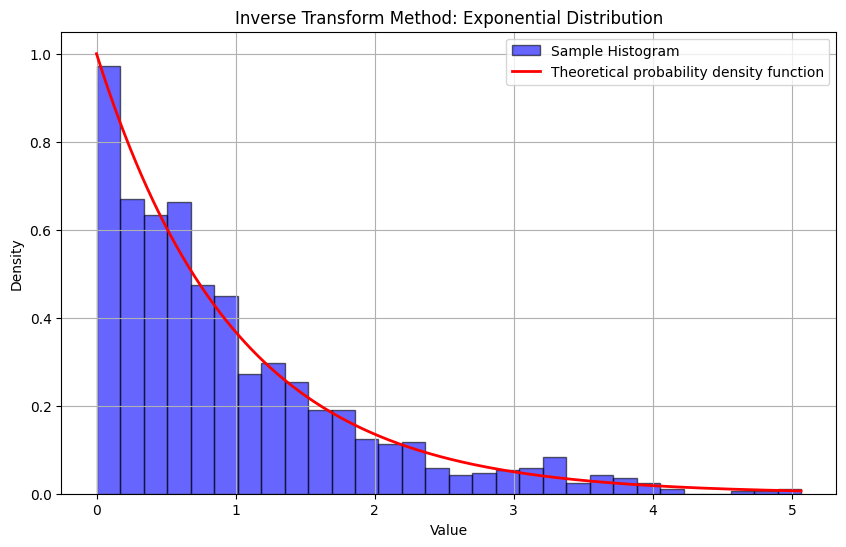

In [7]:
import numpy as np
import matplotlib.pyplot as plt

lambda_param = 1.0

uniform_samples = np.random.uniform(0, 1, 1000)

exponential_samples = -np.log(uniform_samples) / lambda_param

plt.figure(figsize=(10, 6))
plt.hist(exponential_samples, bins=30, density=True, alpha=0.6, color='blue',edgecolor = "black", label="Sample Histogram")

x = np.linspace(0, np.max(exponential_samples), 1000)
pdf = lambda_param * np.exp(-lambda_param * x)
plt.plot(x, pdf, 'r-', lw=2, label="Theoretical probability density function")

plt.title("Inverse Transform Method: Exponential Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

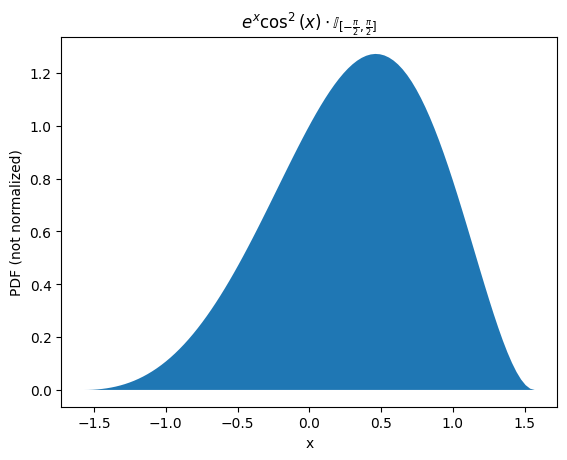

In [8]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

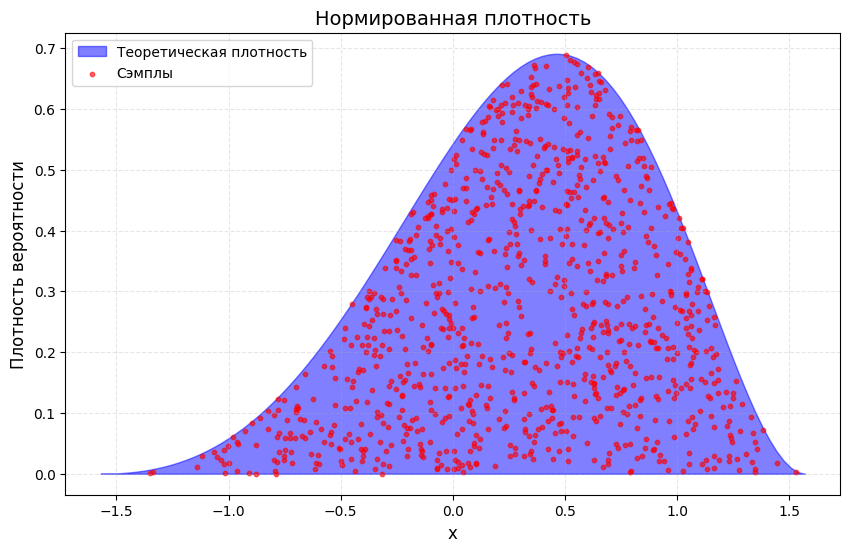

In [10]:
import scipy.integrate as integrate

def den(x, norm):
    return np.exp(x) * np.cos(x) ** 2 / norm * ((x >= -np.pi/2) & (x <= np.pi/2))

num_samples = 1000

inter = integrate.quad(lambda x: np.exp(x) * np.cos(x) ** 2, -np.pi/2, np.pi/2)[0]

x_max = np.arctan(1/2)
max_value = np.exp(x_max) * np.cos(x_max) ** 2 / inter

samples_x, samples_y = [], []

while len(samples_x) < num_samples:
    s = np.random.uniform(-np.pi/2, np.pi/2)
    d = np.random.uniform(0, max_value)

    if (d < den(s, inter)):
        samples_x.append(s)
        samples_y.append(d)

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 / inter

plt.figure(figsize=(10, 6))
plt.fill_between(x, 0, density, color='blue', alpha=0.5, label='Теоретическая плотность')
plt.scatter(samples_x, samples_y, color='red', s=10, alpha=0.6, label='Сэмплы')
plt.ylabel('Плотность вероятности', fontsize=12)
plt.xlabel('x', fontsize=12)
plt.title(r'Нормированная плотность', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

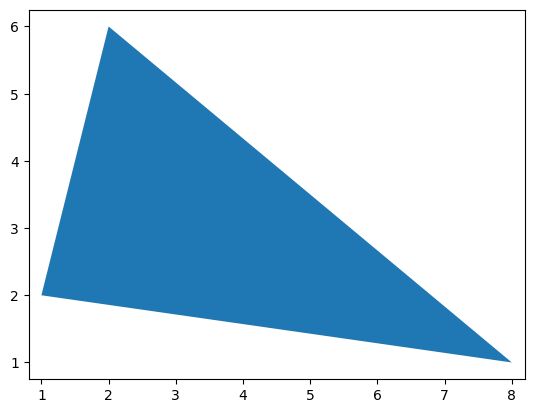

In [14]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

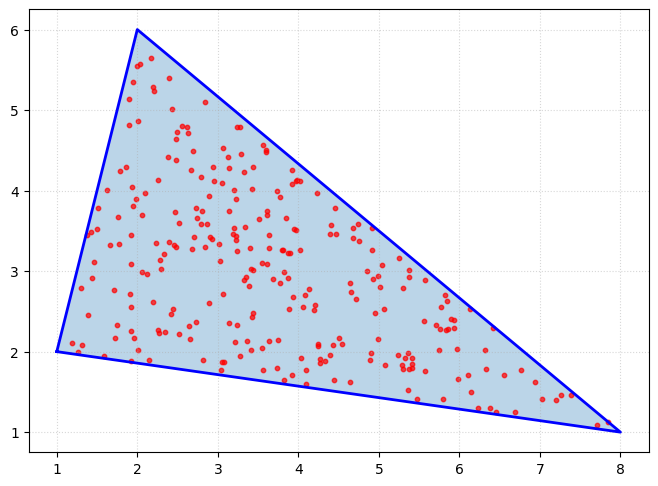

In [15]:
A = [1, 2]
B = [2, 6]
C = [8, 1]

n = 500
u = np.random.rand(n)
v = np.random.rand(n)
mask = u + v < 1
u = u[mask][:n]
v = v[mask][:n]

points = np.column_stack([
    (1 - u - v) * A[0] + u * B[0] + v * C[0],
    (1 - u - v) * A[1] + u * B[1] + v * C[1]
])

plt.figure(figsize=(8, 6))
plt.fill([A[0], B[0], C[0]], [A[1], B[1], C[1]], alpha=0.3)
plt.plot([A[0], B[0], C[0], A[0]], [A[1], B[1], C[1], A[1]], 'b-', linewidth=2)
plt.scatter(points[:,0], points[:,1], color='red', s=10, alpha=0.7)
plt.gca().set_aspect('equal')

plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

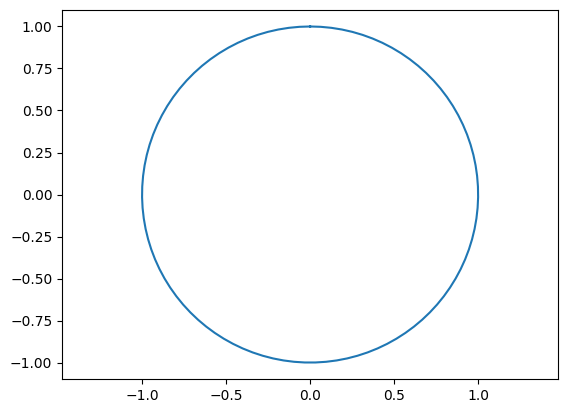

In [16]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

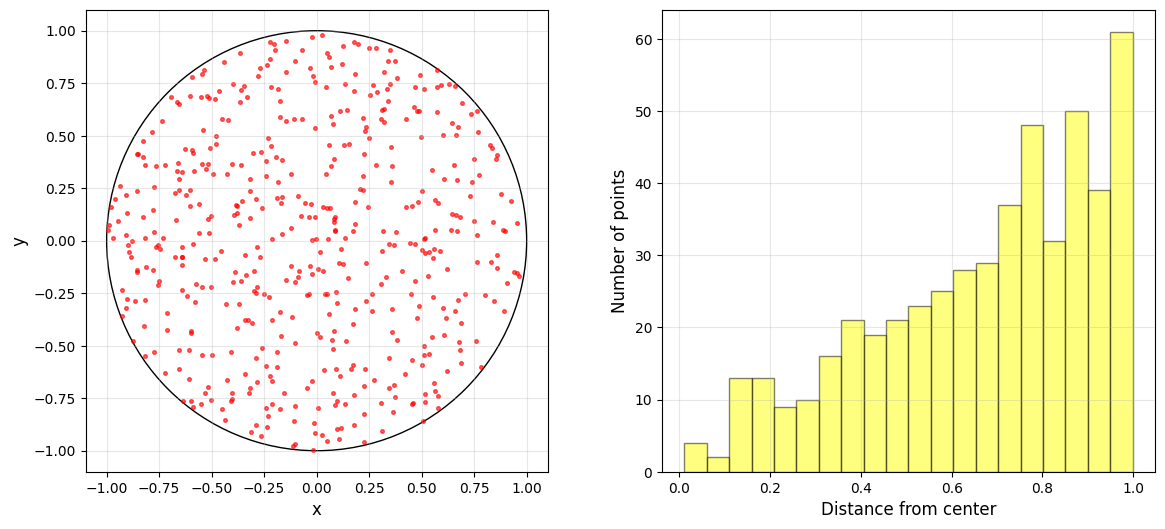

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def sample_circle(n, seed = 1):
    np.random.seed(seed)
    r_squared = np.random.rand(n)
    theta = 2 * np.pi * np.random.rand(n)

    r = np.sqrt(r_squared)
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.column_stack((x, y))

samples = sample_circle(500, seed = 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))
circle = plt.Circle((0, 0), 1, fill = False, edgecolor = "black")
ax1.add_patch(circle)
ax1.scatter(samples[:, 0], samples[:, 1], s = 7, alpha = 0.6, color = "red")
ax1.set_xlabel("x", fontsize = 12)
ax1.set_ylabel("y", fontsize = 12)
ax1.set_aspect("equal")
ax1.grid(True, alpha = 0.3)
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)

distances = np.sqrt(samples[:, 0] ** 2 + samples[:, 1] ** 2)
counts, bins, patches = ax2.hist(distances, bins = 20, edgecolor = "black", alpha = 0.5,
                                  color = "yellow", density = False)
ax2.set_xlabel("Distance from center", fontsize = 12)
ax2.set_ylabel("Number of points", fontsize = 12)
ax2.grid(True, alpha = 0.3)
plt.show()

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

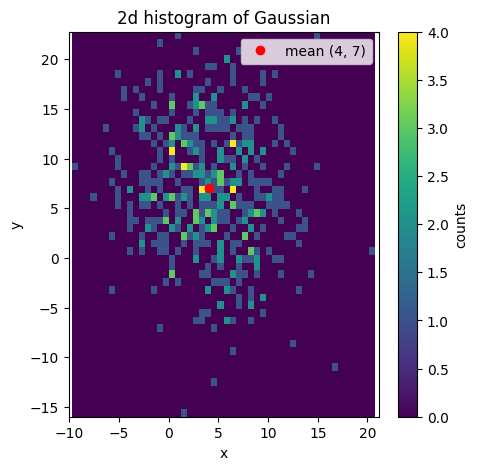

mean: [3.93904941 6.90845079]
covariance:
 [[19.91330374 -3.98899639]
 [-3.98899639 39.82565426]]
true mean: [4 7]
true covariance:
 [[20 -4]
 [-4 40]]


In [43]:
N = 500
n_pairs = N // 2

Z = []
while len(Z) < N:
    x, y = np.random.rand(2) * 2 - 1
    s = x**2 + y**2
    if 0 < s < 1:
        w = np.sqrt(-2 * np.log(s) / s)
        Z.append([x * w, y * w])
        Z.append([y * w, -x * w])

Z = np.array(Z[:N])

sigma = np.array([[20, -4], [-4, 40]])
A = np.linalg.cholesky(sigma)
mu = np.array([4, 7])

X = mu + Z @ A.T

plt.figure(figsize=(5, 5))
plt.hist2d(X[:, 0], X[:, 1], bins=50, cmap='viridis')
plt.colorbar(label='counts')
plt.plot(mu[0], mu[1], 'ro', label='mean (4, 7)')
plt.title('2d histogram of Gaussian')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.axis('equal')
plt.show()

sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X.T)
print("mean:", sample_mean)
print("covariance:\n", sample_cov)
print("true mean:", mu)
print("true covariance:\n", sigma)